## I. POCA class

#### This class performs the PoCA reconstruction from a given csv file containing the hit information from the detector.
#### It is implicitly used by `precompute_poca.py`, which processes all the csv files in a given directory to pre-compute the PoCA-level information which is needed for training an nn model.
#### The user can, however, instantiate the POCA class with a specific csv file to do the reconstruction and visualize PoCA density projections. The POCA object can also be used as a diagnostic to visualize the voxelized input channels to the nn model.

In [1]:
from src.poca_reconstruction import POCA

#### Create an instance of the POCA class with the path to a specific csv file of hit information. The user has to define the VOI xyz limits, in mm, which must be compatible with the ground truth for training.

In [2]:
poca = POCA(
     "/nfs/user/zdaher/twoBoxesInHost/processed_root/H_G4_Be_B1_G4_U_B2_G4_Pb_T40_processed.csv",
    xyz_min = (-500, -400, -1200),
    xyz_max = (500, 400, -600),
    )

poca.poca returns the poca xyz positions (shape: N_poca, xyz)

In [3]:
poca.poca.shape

(260142, 3)

The `plot_poca_projections` method is used to plot projections of the PoCA density cloud.

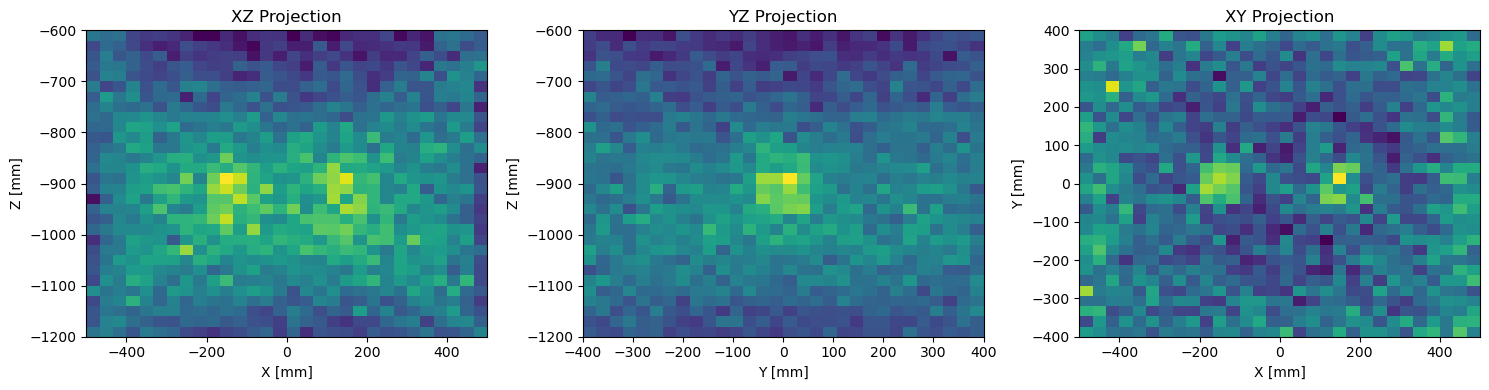

In [4]:
poca.plot_poca_projections(poca.poca, bins = 30)

The precomputed PoCA grids of all the hit csv files, which are used for training, are obtained by executing `utils/precompute_poca.py`.
The `MuonDataset` class is used for loading the training/validation/test datasets by iterating over the saved PoCA files. Below is an example usage of this dataset class.

## II. MuonDataset class

In [6]:
from src.data import MuonDataset

#### Define the path to saved PoCA files, and to to the corresponding ground truth maps.

#### Let's have a look at the train dataset of the scenario where there are two small bozes in a larger host box
#### the datasets below correspond to a ground truth map voxel size of 5 cm

In [7]:
poca_dir = '/nfs/user/zdaher/twoBoxesInHost/dataset_vox05/train/poca_voxels' 
target_dir = '/nfs/user/zdaher/twoBoxesInHost/dataset_vox05/train/density_maps'

In [8]:
dataset = MuonDataset(
    poca_dir=poca_dir,
    target_dir=target_dir,
    normalize_stats=None
)

print(f"Dataset size: {len(dataset)} samples") # number of samples found
print(f"Grid size D: {dataset.D}")
print(f"VOI min: {dataset.voi_min}, VOI max: {dataset.voi_max}")

Dataset size: 1200 samples
Grid size D: 22
VOI min: [ -600.  -600. -1600.], VOI max: [ 600.  600. -300.]


#### Let's have a look at a sample

In [9]:
x, tgt, mask, name = dataset[0]

print("Input shape:", x.shape)          # (3, D, D, D)
print("Target shape:", tgt.shape)       # (1, D, D, D)
print("Mask shape:", mask.shape)        # (1, D, D, D)
print("Name:", name) # the host box material follows H_G4, and the two small boxes materials follow B1_G4 and B2_G4, respectively. The T40 corresponds to the 40k muons used to reconstruct the POCA point cloud.

Input shape: (2, 22, 22, 22)
Target shape: (1, 22, 18, 14)
Mask shape: (1, 22, 22, 22)
Name: H_G4_Be_B1_G4_Al_B2_G4_Pb


#### The first dimension of the input shape is the number of input channels to our nn. Notice that there it is possible to have a mismatch between the grid sizes of the input channels and the ground truth (target). This will be accounted for during training, by cropping the output channels of the prediction grids before loss backpropagation. 

### Visualizing a slice

#### Below is an example plot of XY slices (at mid-z) of the three channel grids.


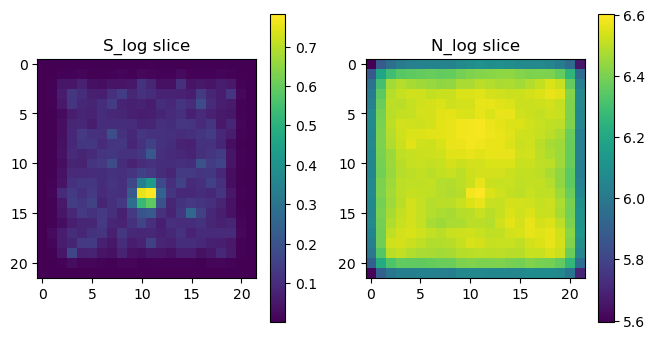

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# choosing the middle slice along the z-axis, where the two boxes are located
i = dataset.D // 2

plt.figure(figsize=(12,4))
plt.subplot(131); plt.title("S_log slice"); plt.imshow(x[0,:, :, i]); plt.colorbar();
plt.subplot(132); plt.title("N_log slice"); plt.imshow(x[1,:, :, i]); plt.colorbar()

plt.show()


### Using DataLoader
#### An instance of a DataLoader class is used during training to load batches of these datasets.

In [11]:
import torch
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4, # set to 0 if error appears
    pin_memory=True
)

for x, tgt, mask, names in loader:
    print("Batch X:", x.shape)     # (B, 3, D, D, D)
    print("Batch tgt:", tgt.shape) # (B, 1, D, D, D)
    print("Batch mask:", mask.shape)  # (B, 1, D, D, D)
    break


Batch X: torch.Size([4, 2, 22, 22, 22])
Batch tgt: torch.Size([4, 1, 22, 18, 14])
Batch mask: torch.Size([4, 1, 22, 22, 22])


#### Notice how DataLoader automatically converts the arrays to torch tensors.
#### Also note that first dimension of these loaded tensors is the batch size, i.e. number of samples loaded at a time.

## ProbUNet3D model

#### We now create an object model to train as an example.

In [12]:
from src.model import ProbUNet3D

model = ProbUNet3D(
    in_channels=2,  # S, N
    out_channels=2,  # mean mu, std log(sigma^2))
    base_features=16,
    depth=4
)

#### A single prediction of the model on an iteration of the DataLoader

In [13]:
x, tgt, mask, name = next(iter(loader))

x = x
tgt = tgt
mask = mask

pred = model(x)

print("pred shape:", pred.shape)  # (B, 2, D, D, D)
mu = pred[:,0:1]
log_sigma = pred[:,1:2]

print("mu range:", mu.min().item(), mu.max().item())
print("log_sigma range:", log_sigma.min().item(), log_sigma.max().item())


pred shape: torch.Size([4, 2, 22, 22, 22])
mu range: 0.5635786056518555 3.324671506881714
log_sigma range: -1.2113189697265625 0.6911869645118713


#### Below is an example training loop for a few epochs. 

#### First we define the function to crop the output channels so that they match the ground truth.

In [14]:
def center_crop(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    Crop pred to match target spatial dimensions, symmetrically.
    Assumes pred and target are [B, C, D, H, W].
    """
    _, _, Dp, Hp, Wp = pred.shape
    _, _, Dt, Ht, Wt = target.shape

    # Compute cropping indices
    d1 = (Dp - Dt) // 2
    d2 = d1 + Dt

    h1 = (Hp - Ht) // 2
    h2 = h1 + Ht

    w1 = (Wp - Wt) // 2
    w2 = w1 + Wt

    return pred[:, :, d1:d2, h1:h2, w1:w2]

#### The NLL loss will return a tuple (base_loss, monitor_loss), where `base_loss` is the loss to be backpropagated for training, and `monitor_loss` is the loss to be monitored for model evaluation. This is because the $\beta$-NLL is used, where the loss is multiplied by a detached factor to stabilize learning.

In [15]:
import torch
from torch.utils.data import DataLoader

from src.data import MuonDataset
from src.model import ProbUNet3D, nll_loss_masked

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

data_path = "/nfs/user/zdaher/twoBoxesInHost/dataset_vox05/"

train_dataset = MuonDataset(
    poca_dir   = f"{data_path}/train/poca_voxels",
    target_dir = f"{data_path}/train/density_maps",
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4, # set to 0 if issues occur
    pin_memory=False,
)

# Model + Optimizer
model = ProbUNet3D(
    in_channels=2,
    out_channels=2,
    base_features=16,
    depth=3,
    use_resblock= True
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2, weight_decay=1e-3)

# example of a few training epochs

n_epochs = 2

for epoch in range(1, n_epochs + 1):

    model.train()
    total_loss = 0
    n_batches = 0

    print(f"\nEpoch {epoch}/{n_epochs}")

    for batch_idx, (x, tgt, mask, name) in enumerate(train_loader):
        
        x    = x.to(device)
        tgt  = tgt.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()

        pred = model(x)

        pred = center_crop(pred, tgt)
        mask = center_crop(mask, tgt)   

        base_loss, monitor_loss = nll_loss_masked(pred, tgt, mask) # base_loss used for optimization

        base_loss.backward()
        optimizer.step()

        total_loss += monitor_loss # monitor_loss used for monitoring
        n_batches += 1

        if batch_idx % 5 == 0:
            print(f"  batch {batch_idx:3d} | loss={total_loss.item():.4f}")

    print(f"Epoch {epoch} avg loss = {total_loss / n_batches:.4f}")


Device: cpu

Epoch 1/2


  batch   0 | loss=1.8627
  batch   5 | loss=15.3496
  batch  10 | loss=23.8899
  batch  15 | loss=32.3061
Epoch 1 avg loss = 1.9581

Epoch 2/2
  batch   0 | loss=1.6419
  batch   5 | loss=9.7591
  batch  10 | loss=17.8727
  batch  15 | loss=25.3175
Epoch 2 avg loss = 1.5499


#### While it is possible to train the model in a jupyter notebook, we will train with running a script (`train/train.py`) in terminal mode for the sake of speed. 

#### Inspecting the prediction of the above trained model after the two epochs. We will crop the shapes of all grids for comparison.

Input shape: torch.Size([4, 2, 22, 22, 22])
Target shape: torch.Size([4, 1, 22, 18, 14])
Mask shape: torch.Size([4, 1, 22, 22, 22])
Name: ('H_G4_CONCRETE_B1_G4_U_B2_G4_Al', 'H_G4_CONCRETE_B1_G4_U_B2_G4_Pb', 'H_G4_CONCRETE_B1_G4_Al_B2_G4_U', 'H_G4_CONCRETE_B1_G4_Al_B2_G4_Pb')
Pred shape: torch.Size([4, 2, 22, 18, 14])
S_log shape: (22, 18, 14)
N_log shape: (22, 18, 14)
mu shape: (22, 18, 14)
sigma shape: (22, 18, 14)
14
gt shape: (1, 22, 18, 14)


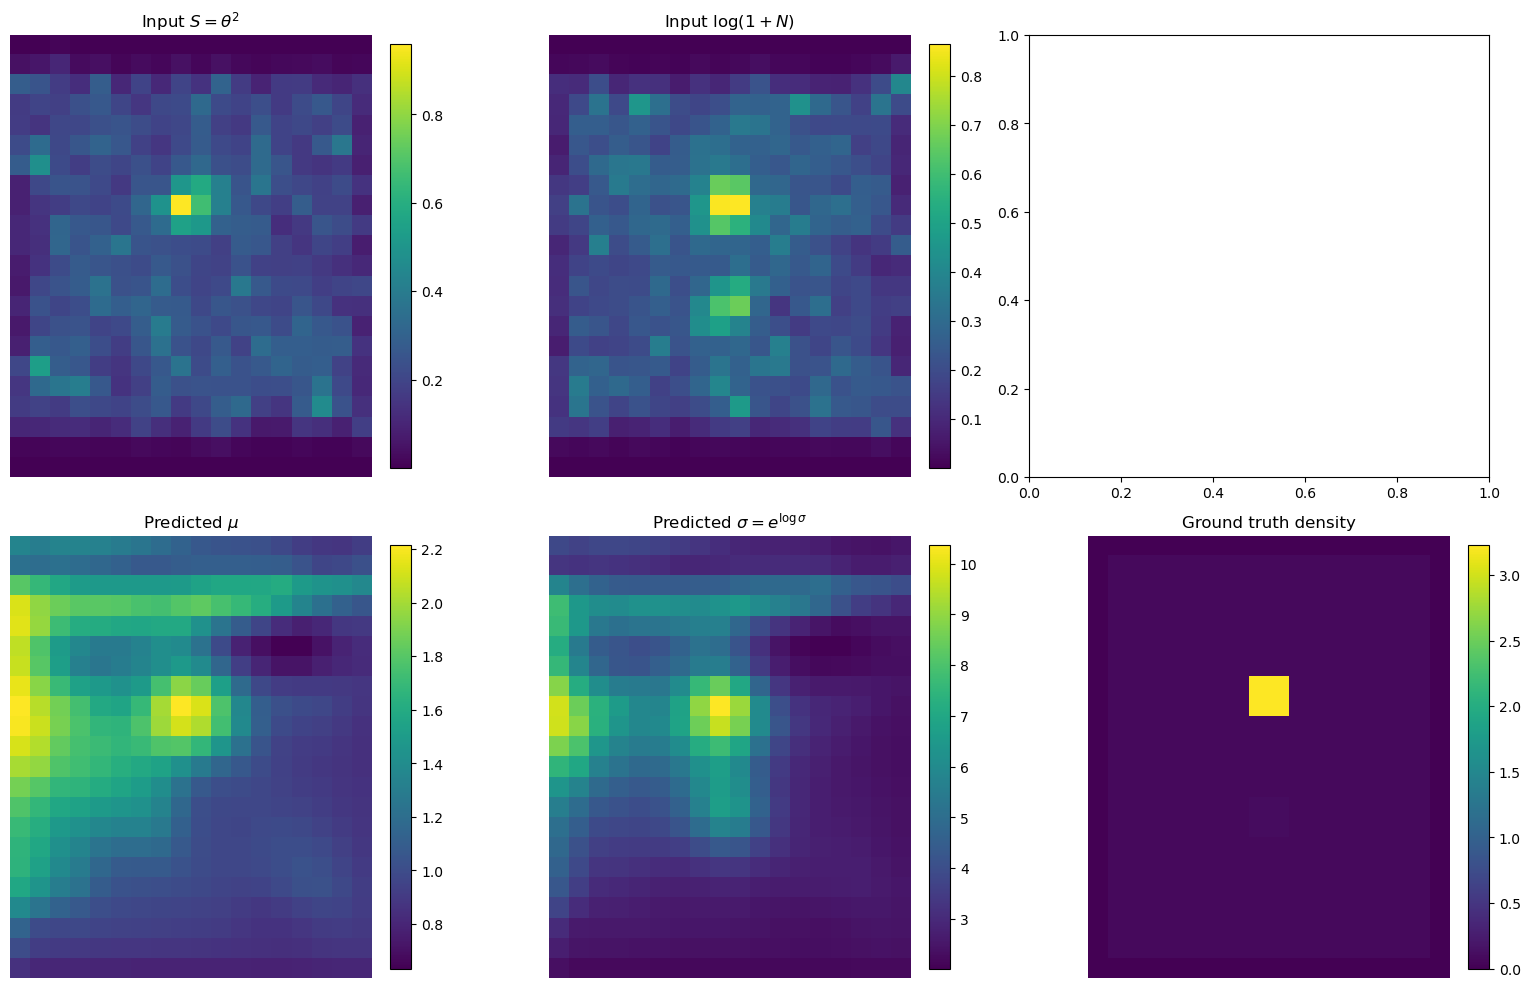

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torch

x, tgt, mask, name = next(iter(loader))

print ("Input shape:", x.shape)          # (B, 3, D, D, D)
print ("Target shape:", tgt.shape)       # (B, 1, D, D, D)
print ("Mask shape:", mask.shape)        # (B, 1, D, D, D)
print ("Name:", name)

pred = model(x.to(device))
pred = center_crop(pred, tgt)

print ("Pred shape:", pred.shape)  # (B, 2, D, D, D)

S_log           = x[0]
N_log       = x[1]

S_log = center_crop(S_log.unsqueeze(0), tgt).squeeze(0).detach().cpu().numpy()[0]
N_log = center_crop(N_log.unsqueeze(0), tgt).squeeze(0).detach().cpu().numpy()[0]

print ("S_log shape:", S_log.shape)          # (D, D, D)
print ("N_log shape:", N_log.shape)  # (D, D, D)

gt          = tgt[0].detach().cpu().numpy()

mu          = pred[0]
sigma2       = torch.exp(pred[1])

# crop outputs to match gt dimensions
mu = center_crop(mu.unsqueeze(0), tgt).squeeze(0).detach().cpu().numpy()[0]
sigma = center_crop(sigma2.unsqueeze(0), tgt).squeeze(0).detach().cpu().numpy()[0]


print ("mu shape:", mu.shape)          # (D, D, D)
print ("sigma shape:", sigma.shape)    # (D, D, D)
# Mid-slice
D = mu.shape[2]
z = D//2

print (D)


# ----------------------------------------
# Plot
# ----------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(16, 10))

def show(ax, data, title):
    im = ax.imshow(data, cmap='viridis')
    ax.set_title(title)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Inputs
show(axs[0,0], S_log[:, : ,z], r"Input $S = \theta^2$")
show(axs[0,1], N_log[:, : ,z], r"Input $\log(1+N)$")

# Outputs
show(axs[1,0], mu[:, : ,z], r"Predicted $\mu$")
show(axs[1,1], sigma[:, : ,z], r"Predicted $\sigma = e^{\log \sigma}$")

# Ground truth
print ("gt shape:", gt.shape)  # (D, D, D)  
show(axs[1,2], gt[0, :, : ,z], "Ground truth density")

plt.tight_layout()
plt.show()



#### For proper training, a common practice is to split the dataset into separate training/validation/testing datasets in 80/10/10 fractions. The model is validated against the validation dataset during training but without updating model parameters to detect any overfitting. The testing dataset is evaluated after training in evaluation mode (model.eval()).

#### The script `train/split_dataset.py` splits our full dataset and stores the different datasets in separate folders.

#### Below, we show an example of loading a pre-trained model, whose final state is saved in `train_outputs_twoBoxesInHost`. The model was trained on a split dataset found in `/nfs/user/zdaher/twoBoxesInHost/dataset_vox05/train/`.

#### The loaded model will be evaluated with a test dataset `/nfs/user/zdaher/twoBoxesInHost/dataset_vox05/test/`

In [17]:
from src.model import ProbUNet3D 
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

ckpt_path = "train_outputs_twoBoxesInHost/best_model.pt"

ckpt = torch.load(ckpt_path, map_location=device)

print(ckpt.keys())

model = ProbUNet3D(in_channels=2, out_channels=2, depth =3, base_features=16, use_resblock=True).to(device)
model.load_state_dict(ckpt)

model.eval()

print("Loaded model from:", ckpt_path)

odict_keys(['downs.0.0.weight', 'downs.0.1.weight', 'downs.0.1.bias', 'downs.0.1.running_mean', 'downs.0.1.running_var', 'downs.0.1.num_batches_tracked', 'downs.0.3.conv1.weight', 'downs.0.3.bn1.weight', 'downs.0.3.bn1.bias', 'downs.0.3.bn1.running_mean', 'downs.0.3.bn1.running_var', 'downs.0.3.bn1.num_batches_tracked', 'downs.0.3.conv2.weight', 'downs.0.3.bn2.weight', 'downs.0.3.bn2.bias', 'downs.0.3.bn2.running_mean', 'downs.0.3.bn2.running_var', 'downs.0.3.bn2.num_batches_tracked', 'downs.1.0.weight', 'downs.1.1.weight', 'downs.1.1.bias', 'downs.1.1.running_mean', 'downs.1.1.running_var', 'downs.1.1.num_batches_tracked', 'downs.1.3.conv1.weight', 'downs.1.3.bn1.weight', 'downs.1.3.bn1.bias', 'downs.1.3.bn1.running_mean', 'downs.1.3.bn1.running_var', 'downs.1.3.bn1.num_batches_tracked', 'downs.1.3.conv2.weight', 'downs.1.3.bn2.weight', 'downs.1.3.bn2.bias', 'downs.1.3.bn2.running_mean', 'downs.1.3.bn2.running_var', 'downs.1.3.bn2.num_batches_tracked', 'downs.2.0.weight', 'downs.2.1.w

/tmp/ipykernel_3928521/2311227559.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


### creating a validation dataloader for evaluation

In [18]:
from src.data import MuonDataset
from torch.utils.data import DataLoader

poca_dir   = "/nfs/user/zdaher/twoBoxesInHost/dataset_vox05/val/poca_voxels/"
target_dir = "/nfs/user/zdaher/twoBoxesInHost/dataset_vox05/val/density_maps/"

val_ds = MuonDataset(poca_dir, target_dir)
val_dl = DataLoader(val_ds, batch_size=300, num_workers=0)

### Obtaining model prediction on the validation dataset

In [19]:
x, y, mask, name = next(iter(val_dl))
x = x.to(device)
y = y.to(device)
mask = mask.to(device)
print(name)

with torch.no_grad():
    pred = model(x)

mu = pred[:, 0]
sigma =torch.exp(pred[:, 1]).sqrt()

print("Shapes:")
print("mu:", mu.shape)
print("sigma:", sigma.shape)
print("target:", y.shape)

('H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G4_Al_B2_G4_Al', 'H_G4_Be_B1_G

### an example to check the names of the samples in the dataset, and find the indices of those containing a certain material in their name 


In [20]:
mat_str = "Pb"
mat_indices = [i for i, n in enumerate(name) if mat_str in n]

print(f"Indices with '{mat_str}' in name:", mat_indices)

Indices with 'Pb' in name: [200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299]


In [21]:
mat_str = "Al"
mat_indices = [i for i, n in enumerate(name) if mat_str in n]

print(f"Indices with '{mat_str}' in name:", mat_indices)

Indices with 'Al' in name: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199]


### Example : Pb

torch.Size([300, 2, 22, 22, 22])
torch.Size([22, 22])


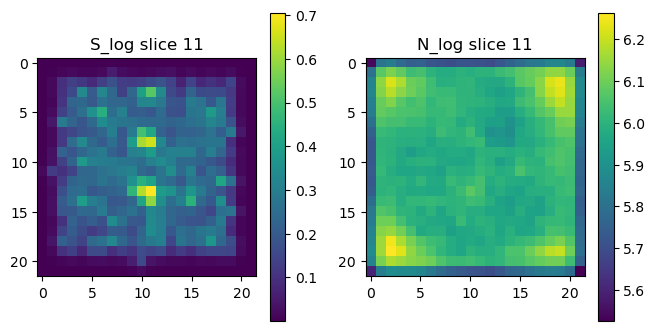

In [33]:
import matplotlib.pyplot as plt
# plotting input channels 
# select batch index
b = 200
i= 11 # slice index along z
print (x.shape)
S_log = x[:,0,:, :, i]
N_log = x[:, 1,:, :, i]

print (x[b,0,:, :, i].shape)
plt.figure(figsize=(12,4))
plt.subplot(131); plt.title(f"S_log slice {i}"); plt.imshow(S_log[b].numpy()); plt.colorbar();
plt.subplot(132); plt.title(f"N_log slice {i}"); plt.imshow(N_log[b].numpy()); plt.colorbar()
plt.show()


### Example : Al

torch.Size([300, 2, 22, 22, 22])
torch.Size([22, 22])


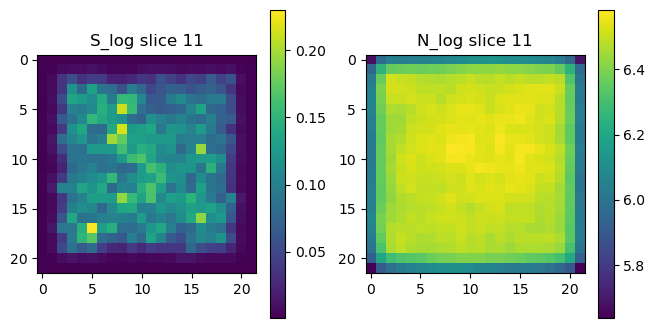

In [34]:
import matplotlib.pyplot as plt
# plotting input channels 
# select batch index
b = 0
i= 11
print (x.shape)
S_log = x[:,0,:, :, i]
N_log = x[:, 1,:, :, i]

print (x[b,0,:, :, i].shape)
plt.figure(figsize=(12,4))
plt.subplot(131); plt.title(f"S_log slice {i}"); plt.imshow(S_log[b].numpy()); plt.colorbar();
plt.subplot(132); plt.title(f"N_log slice {i}"); plt.imshow(N_log[b].numpy()); plt.colorbar()
plt.show()


### Plotting model predictions of the Pb sample

Note that the focus is on the prediction of the smaller cubes, sine the background voxels are down-weighted during training

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def plot_slices(mu, sigma, target, batch_idx=0, axis="z", n_slices=4):
    """
    mu, sigma, target: tensors of shape [B, 1, D, D, D] or [B, D, D, D]
    """
    # Crop to target dimensions
    mu_b = center_crop(mu.unsqueeze(0), target).squeeze(0)[batch_idx]
    sigma_b = center_crop(sigma.unsqueeze(0), target).squeeze(0)[batch_idx]
    target_b = target.squeeze()[batch_idx]

    if mu_b.ndim != 3:
        raise ValueError(f"Expected (D,D,D), got {mu_b.shape}")

    D = mu_b.shape[0]

    # Choose slice indices 
    idxs = np.linspace(0, D-1, n_slices).astype(int)

    # --- Compute global vmin/vmax for each channel ---
    mu_min,     mu_max     = float(mu_b.min()),     float(mu_b.max())
    sig_min,    sig_max    = float(sigma_b.min()),  float(sigma_b.max())
    tgt_min,    tgt_max    = float(target_b.min()), float(target_b.max())

    # global min max for both mu and tgt 
    pred_min, pred_max = np.min([mu_min, tgt_min]), np.max([mu_max, tgt_max])
    

    # Prepare figure
    fig, axs = plt.subplots(n_slices, 3, figsize=(13, 4*n_slices))

    for row, idx in enumerate(idxs):

        # Extract slice 
        if axis == "z":
            s_mu     = mu_b[:, :, idx]
            s_sigma  = sigma_b[:, :, idx]
            s_target = target_b[:, :, idx]
        elif axis == "y":
            s_mu     = mu_b[:, idx, :]
            s_sigma  = sigma_b[:, idx, :]
            s_target = target_b[:, idx, :]
        elif axis == "x":
            s_mu     = mu_b[idx, :, :]
            s_sigma  = sigma_b[idx, :, :]
            s_target = target_b[idx, :, :]
        else:
            raise ValueError("axis must be x, y, or z")

        # mean (mu)
        im0 = axs[row, 0].imshow(s_mu.numpy(), cmap="viridis",
                                 vmin=pred_min, vmax=pred_max
                                )
                                
        axs[row, 0].set_title(f"μ (slice {idx})")
        fig.colorbar(im0, ax=axs[row, 0], fraction=0.046, pad=0.04)

        # sigma
        im1 = axs[row, 1].imshow(s_sigma.numpy(), cmap="viridis",
                                 vmin=sig_min, vmax=sig_max
                                )
        axs[row, 1].set_title("σ")
        fig.colorbar(im1, ax=axs[row, 1], fraction=0.046, pad=0.04)

        # target (ground truth)
        im2 = axs[row, 2].imshow(s_target.numpy(), cmap="viridis",
                                 vmin=pred_min, vmax=pred_max
                                )
        axs[row, 2].set_title("target")
        fig.colorbar(im2, ax=axs[row, 2], fraction=0.046, pad=0.04)

        for col in range(3):
            axs[row, col].axis("off")

    plt.tight_layout()
    plt.savefig("plots/slices.png")
    plt.show()


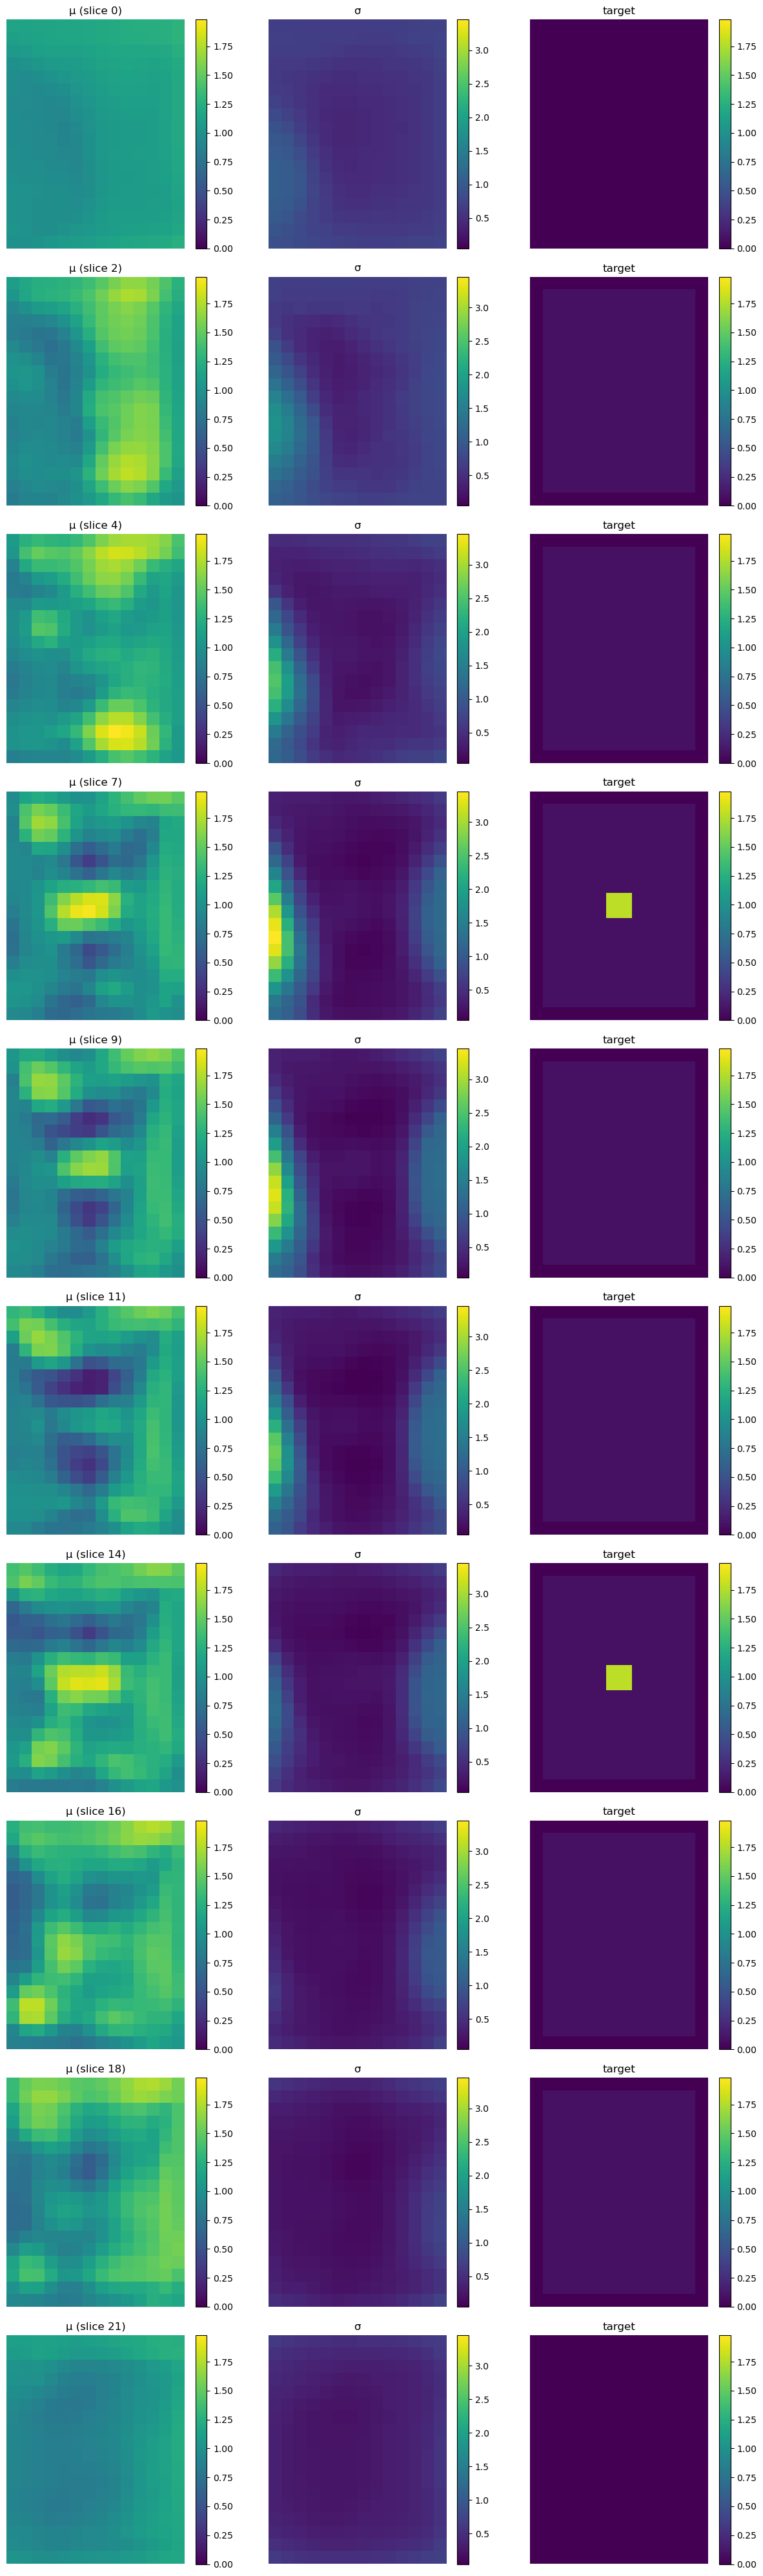

In [36]:
plot_slices(mu, sigma, y, axis="x", n_slices=10, batch_idx=200)

### Checking predicted aleatoric uncertainty calibration
Note that since background voxels are weighted down, we focus on he target smaller blocks for evaluation 

mu_b shape: torch.Size([22, 18, 14])
sigma_b shape: torch.Size([22, 18, 14])
target_b shape: torch.Size([22, 18, 14])
0.023109372705221176 3.865394115447998
tensor([])
tensor([])
tensor([])
tensor([0.1576, 0.1749, 0.3402, 0.1570])
tensor([])
tensor([])
tensor([0.0231, 0.0697, 0.1958, 0.2351])
tensor([])
tensor([])
tensor([])


/tmp/ipykernel_3928521/3267359433.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


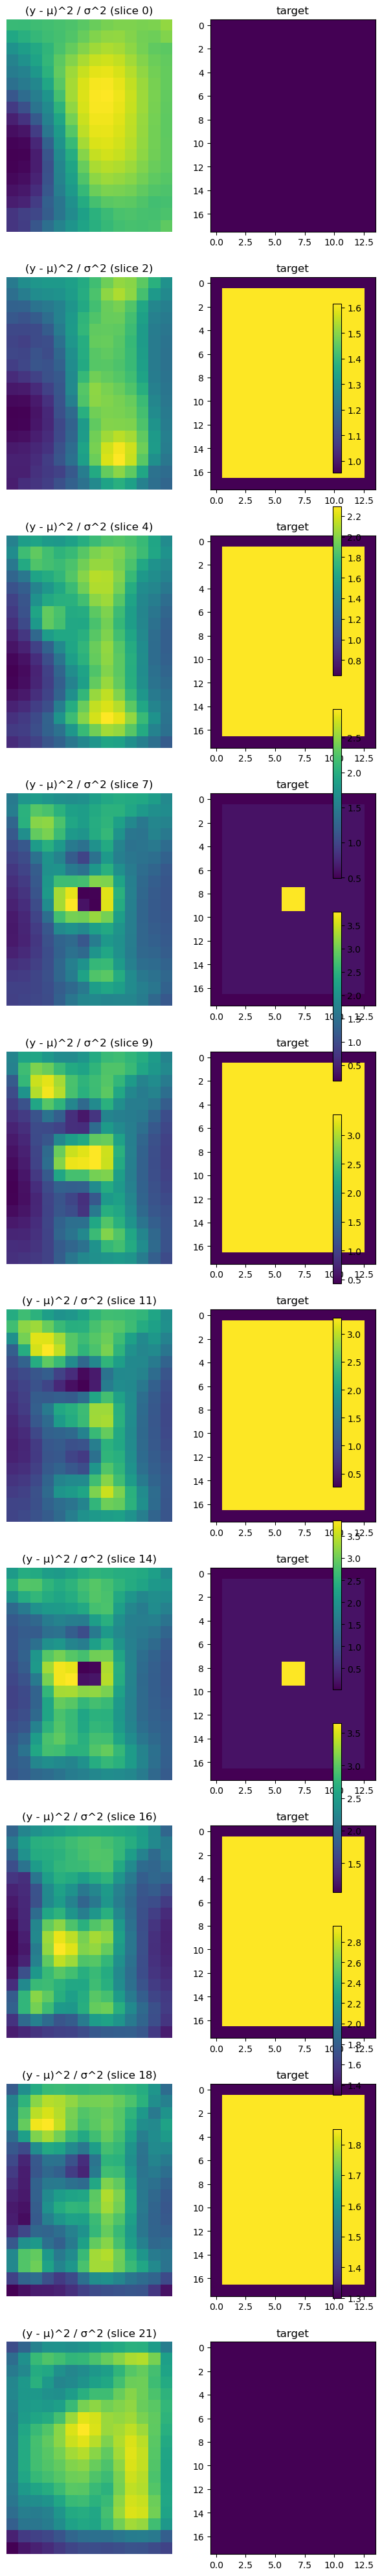

In [38]:
def plot_nll_ratio(mu, sigma, target, batch_idx=1, axis="z", n_slices=4, eps=1e-9):
    """
    Plots (y - μ)^2 / σ^2 per slice to visualize how the network balances error vs uncertainty.
    Good values are close to 0.
    """
    mu_b = center_crop(mu.unsqueeze(0), target).squeeze(0)[batch_idx]
    sigma_b = center_crop(sigma.unsqueeze(0), target).squeeze(0)[batch_idx]
    target_b = target.squeeze()[batch_idx]

    print ("mu_b shape:", mu_b.shape)
    print ("sigma_b shape:", sigma_b.shape)
    print ("target_b shape:", target_b.shape)

    if mu_b.ndim != 3:
        raise ValueError(f"Expected (D,D,D), got {mu_b.shape}")

    D = mu_b.shape[0]
    idxs = np.linspace(0, D-1, n_slices).astype(int)

    fig, axs = plt.subplots(n_slices, 2, figsize=(6, 4*n_slices))

    ratio = (((target_b - mu_b)**2) / (sigma_b + eps))**0.5

    min = float(ratio.min())
    max = float(ratio.max())
    print (min, max)


    for row, idx in enumerate(idxs):
        if axis == "z":
            s_mu     = mu_b[:, :, idx]
            s_sigma  = sigma_b[:, :, idx]
            s_target = target_b[:, :, idx]
        elif axis == "y":
            s_mu     = mu_b[:, idx, :]
            s_sigma  = sigma_b[:, idx, :]
            s_target = target_b[:, idx, :]
        elif axis == "x":
            s_mu     = mu_b[idx, :, :]
            s_sigma  = sigma_b[idx, :, :]
            s_target = target_b[idx, :, :]
        else:
            raise ValueError("axis must be x, y, or z")

        ratio = (((s_target - s_mu)**2) / (s_sigma + eps))**0.5
        print(ratio[s_target>0.1])

        im = axs[row][0].imshow(ratio.numpy(), cmap="viridis")
        axs[row][0].set_title(f"(y - μ)^2 / σ^2 (slice {idx})")
        fig.colorbar(im, ax=axs[row], fraction=0.046, pad=0.04)
        axs[row][0].axis("off")

        # --- target ---
        im2 = axs[row, 1].imshow(s_target.numpy(), cmap="viridis",
                                 # vmin=pred_min, vmax=pred_max
                                )
        axs[row, 1].set_title("target")

    plt.tight_layout()
    plt.show()

plot_nll_ratio(mu, sigma, y, axis="x", n_slices=10, batch_idx=200)


### Loss history 

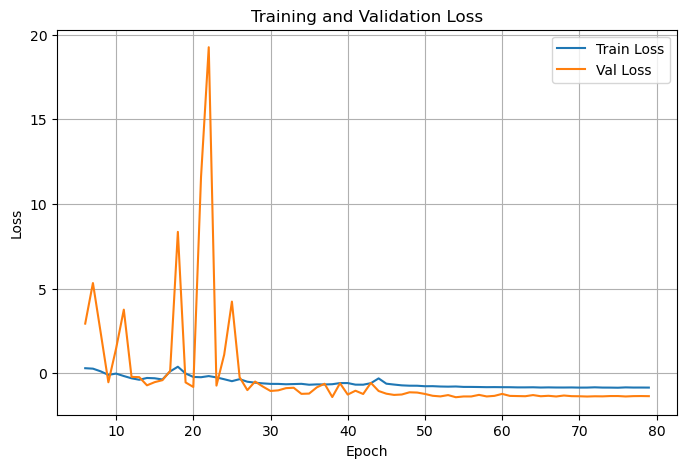

In [39]:
import re
import matplotlib.pyplot as plt

log_file = "train_outputs_twoBoxesInHost/train.log"

train_losses = []
val_losses = []

# regex to match epoch lines
pattern = re.compile(r"Epoch\s+\d+\s+\|\s+Train\s+([-\d.e]+)\s+\|\s+Val\s+([-\d.e]+)")

with open(log_file) as f:
    for line in f:
        m = pattern.search(line)
        if m:
            train_losses.append(float(m.group(1)))
            val_losses.append(float(m.group(2)))

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(8,5))
plt.plot(epochs[5:], train_losses[5:], label="Train Loss")
plt.plot(epochs[5:], val_losses[5:], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


#### Full Evaluation on validation and test datasets

In [41]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from src.data import MuonDataset 

plot_dir = "analysis_results_plots"

device = "cuda" if torch.cuda.is_available() else "cpu"

#  Paths to val and test datasets
val_dirs = {
    "poca": "/nfs/user/zdaher/twoBoxesInHost/dataset_vox05/val/poca_voxels/",
    "target": "/nfs/user/zdaher/twoBoxesInHost/dataset_vox05/val/density_maps/"
}
test_dirs = {
    "poca": "/nfs/user/zdaher/twoBoxesInHost/dataset_vox05/test/poca_voxels/",
    "target": "/nfs/user/zdaher/twoBoxesInHost/dataset_vox05/test/density_maps/"
}

# Datasets and loaders
val_ds  = MuonDataset(val_dirs["poca"], val_dirs["target"])
test_ds = MuonDataset(test_dirs["poca"], test_dirs["target"])
val_dl  = DataLoader(val_ds, batch_size=300, num_workers=0)
test_dl = DataLoader(test_ds, batch_size=300, num_workers=0)

# Combine loaders into a list for iteration
loaders = [("val", val_dl), ("test", test_dl)]

# Materials of interest
materials = ["Al", "Pb", "U"]

# Storage for plotting
import os
os.makedirs(plot_dir, exist_ok=True)



In [44]:
# Evaluation
for split_name, loader in loaders:
    all_mu, all_sigma, all_y, all_names = [], [], [], []

    for x, y, mask, name in loader:
        x = x.to(device)
        y = y.to(device)
        mask = mask.to(device)

        with torch.no_grad():
            pred = model(x)
        mu    = pred[:, 0]
        sigma = torch.exp(pred[:, 1])  # variance as sigma^2

        all_mu.append(mu.cpu())
        all_sigma.append(sigma.cpu())
        all_y.append(y.cpu())
        all_names.extend(name)

    # Concatenate all batches
    all_mu    = torch.cat(all_mu, dim=0)
    all_sigma = torch.cat(all_sigma, dim=0)
    all_y     = torch.cat(all_y, dim=0)

    # Loop over materials
    for mat in materials:
        mat_idx = [i for i, n in enumerate(all_names) if mat in n]
        if len(mat_idx) == 0:
            continue

        mu_mat    = all_mu[mat_idx]
        sigma_mat = all_sigma[mat_idx]
        y_mat     = all_y[mat_idx]

        # Squeeze channel dimension if present
        if mu.ndim == 5:   # [B, 1, D, D, D]
            mu    = mu.squeeze(1)
            sigma = sigma.squeeze(1)
        
        # Removing paddings consistently across mu, sigma, and y to match the target dimensions
        mu    = center_crop(mu.unsqueeze(0), y).squeeze(0)
        sigma = center_crop(sigma.unsqueeze(0), y).squeeze(0)

        print(mu.shape, sigma.shape, y.shape)

        # Flatten batch + voxels
        mu_flat    = mu.reshape(-1)
        sigma_flat = sigma.reshape(-1)
        y_flat     = y.view(-1)
        
        # Only target voxels
        mask_target = y_flat > 0.1
        mu_t     = mu_flat[mask_target]
        sigma_t  = sigma_flat[mask_target]
        y_t      = y_flat[mask_target]
        
        print(mu_t.shape, sigma_t.shape, y_t.shape)

        # Compute RMSE per voxel
        rmse = torch.sqrt((mu_t - y_t) ** 2)

        # z-score
        z = (mu_t - y_t) / sigma_t

        # Plot RMSE vs truth
        plt.figure(figsize=(6,4))
        plt.scatter(y_t.numpy(), rmse.numpy(), alpha=0.3)
        plt.xlabel("True density (X0)")
        plt.ylabel("RMSE")
        plt.title(f"{split_name.upper()} - {mat} - RMSE")
        plt.grid(True)
        plt.savefig(f"{plot_dir}/{split_name}_{mat}_rmse.png")
        plt.close()

        # Plot predicted sigma vs truth
        plt.figure(figsize=(6,4))
        plt.scatter(y_t.numpy(), sigma_t.numpy(), alpha=0.3, color='orange')
        plt.xlabel("True density (X0)")
        plt.ylabel("Predicted σ")
        plt.title(f"{split_name.upper()} - {mat} - Predicted σ")
        plt.grid(True)
        plt.savefig(f"{plot_dir}/{split_name}_{mat}_sigma.png")
        plt.close()

        # Plot z-score histogram
        plt.figure(figsize=(6,4))
        plt.hist(z.numpy(), bins=50, color='green', alpha=0.7)
        plt.xlabel("z = (μ - y) / σ")
        plt.ylabel("Counts")
        plt.title(f"{split_name.upper()} - {mat} - z-score")
        plt.grid(True)
        plt.savefig(f"{plot_dir}/{split_name}_{mat}_z.png")
        plt.close()

        print(f"{split_name.upper()} {mat}: voxels={len(mu_t)}, RMSE mean={rmse.mean():.3f}, σ mean={sigma_t.mean():.3f}, z mean={z.mean():.3f}")

torch.Size([300, 22, 18, 14]) torch.Size([300, 22, 18, 14]) torch.Size([300, 1, 22, 18, 14])
torch.Size([4800]) torch.Size([4800]) torch.Size([4800])
VAL Al: voxels=4800, RMSE mean=0.091, σ mean=0.020, z mean=12.271
torch.Size([300, 22, 18, 14]) torch.Size([300, 22, 18, 14]) torch.Size([300, 1, 22, 18, 14])
torch.Size([4800]) torch.Size([4800]) torch.Size([4800])
VAL Pb: voxels=4800, RMSE mean=0.091, σ mean=0.020, z mean=12.271
torch.Size([300, 22, 18, 14]) torch.Size([300, 22, 18, 14]) torch.Size([300, 1, 22, 18, 14])
torch.Size([4800]) torch.Size([4800]) torch.Size([4800])
TEST Pb: voxels=4800, RMSE mean=0.244, σ mean=0.071, z mean=-1.661
torch.Size([300, 22, 18, 14]) torch.Size([300, 22, 18, 14]) torch.Size([300, 1, 22, 18, 14])
torch.Size([4800]) torch.Size([4800]) torch.Size([4800])
TEST U: voxels=4800, RMSE mean=0.244, σ mean=0.071, z mean=-1.661


In [45]:
import matplotlib.pyplot as plt

# Define your desired base size
BIGGER_SIZE = 16

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE-2)   # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE-2)   # fontsize of the tick labels

# --- LEGEND SPECIFIC SETTINGS ---
plt.rc('legend', fontsize=BIGGER_SIZE)    # fontsize of the legend text
plt.rc('legend', title_fontsize=BIGGER_SIZE + 2) # fontsize of the legend title
plt.rc('figure', titlesize=BIGGER_SIZE + 4) # fontsize of the figure title

# Make legend lines thicker to match bigger text
plt.rcParams['legend.handlelength'] = 2
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.edgecolor'] = 'black'

In [ ]:
# analysis.py
import os
import numpy as np
import torch
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from src.data import MuonDataset

# output directory for analysis plots
plot_dir = "analysis_results_plots/"
os.makedirs(plot_dir, exist_ok=True)

# 1. DATA LOADERS

BASE = "/nfs/user/zdaher/twoBoxesInHost/dataset_vox05"

datasets = {
    "val":  MuonDataset(f"{BASE}/val/poca_voxels/",   f"{BASE}/val/density_maps/"),
    "test": MuonDataset(f"{BASE}/test/poca_voxels/",  f"{BASE}/test/density_maps/"),
}
loaders = {
    split: DataLoader(ds, batch_size=300, num_workers=0)
    for split, ds in datasets.items()
}

THRESHOLD = 0.1   # only evaluate target voxels above this


# 2.  MATERIAL PARSING
# Name format:  H_G4_<BKG>_B1_G4_<MAT1>_B2_G4_<MAT2>
# We care about the box materials (MAT1, MAT2).
# We'll assign each sample to whichever box materials appear.

MATERIALS = ["Al", "Pb", "U"]

def parse_materials(name: str):
    """Return set of box materials present in this sample name."""
    parts = name.split("_")
    # tokens after B1_G4 and B2_G4
    mats = set()
    for i, p in enumerate(parts):
        if p in ("B1", "B2") and i + 2 < len(parts):
            mats.add(parts[i + 2])
    return mats


# 3.  INFERENCE: accumulate per-material arrays

# storage:  material -> lists of (truth, mu, sigma) scalars for target voxels
from collections import defaultdict
records = defaultdict(lambda: {"truth": [], "mu": [], "sigma": []})

model.eval()

for split, loader in loaders.items():
    print(f"\n=== Running {split} ===")
    for batch_x, batch_y, batch_mask, batch_names in loader:
        batch_x    = batch_x.to(device)
        batch_y    = batch_y.to(device)
        batch_mask = batch_mask.to(device)

        with torch.no_grad():
            pred = model(batch_x)
            pred = center_crop(pred, batch_y)

        mu    = pred[:, 0]                      # [B, D, D, D]
        mu   = pred[:, 0] 
        sigma = torch.exp(pred[:, 1])  

        for i, name in enumerate(batch_names):
            mats = parse_materials(name)
                
            truth_i = batch_y[i].squeeze().cpu()
            mu_i    = mu[i].squeeze().cpu()
            sig_i   = sigma[i].squeeze().cpu()
        
            
            # mask: target voxels only
            mask_i = (truth_i > THRESHOLD)
            if mask_i.sum() == 0:
                continue
            t_vals  = truth_i[mask_i].numpy()
            m_vals  = mu_i[mask_i].numpy()
            s_vals  = sig_i[mask_i].numpy()

            for mat in mats:
                if mat in MATERIALS:
                    records[mat]["truth"].append(t_vals)
                    records[mat]["mu"].append(m_vals)
                    records[mat]["sigma"].append(s_vals)

    print(f"  done.")

# concatenate
data = {}
for mat in MATERIALS:
    if records[mat]["truth"]:
        data[mat] = {
            "truth": np.concatenate(records[mat]["truth"]),
            "mu":    np.concatenate(records[mat]["mu"]),
            "sigma": np.concatenate(records[mat]["sigma"]),
        }
        print(f"{mat}: {len(data[mat]['truth']):,} target voxels")




=== Running val ===
  done.

=== Running test ===
  done.
Al: 3,200 target voxels
Pb: 3,200 target voxels
U: 3,200 target voxels


In [80]:

# 4. PLOT HELPERS

MAT_COLORS = {"Al": "#2060D6", "Pb": "#6ACC65", "U": "#D65F5F"}
BIN_COUNT  = 60


def bin_stats(x, y, n_bins=BIN_COUNT):
    """Bin y values by x; return (bin_centers, mean_y, std_y)."""
    bins   = np.linspace(np.percentile(x, 1), np.percentile(x, 99), n_bins + 1)
    centers, means, stds = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        idx = (x >= lo) & (x < hi)
        if idx.sum() < 5:
            continue
        centers.append(0.5 * (lo + hi))
        means.append(y[idx].mean())
        stds.append(y[idx].std())
    return np.array(centers), np.array(means), np.array(stds)


# 5. ANALYSIS PLOTS
# 5a.  RMSE per material
# 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = {}
for mat in data.keys():
    d         = data[mat]
    truth_val = d["truth"].mean()
    residuals = d["mu"] - d["truth"]
    
    rmse      = np.sqrt((residuals ** 2).mean())
    rel_rmse  = rmse / truth_val          # RMSE / truth
    rel_bias  = residuals.mean() / truth_val  # mean bias / truth
    
    metrics[mat] = dict(truth=truth_val, rmse=rmse, rel_rmse=rel_rmse, rel_bias=rel_bias)
    print(f"{mat}: truth={truth_val:.3f}  RMSE={rmse:.4f}  relRMSE={rel_rmse*100:.2f}%  relBias={rel_bias*100:.2f}%")

##### subplot 1: absolute RMSE 
ax = axes[0]
for mat in metrics:
    ax.bar(mat, metrics[mat]["rmse"], color=MAT_COLORS[mat], alpha=0.8)
    ax.text(mat, metrics[mat]["rmse"]*1.02, f"{metrics[mat]['rmse']:.4f}",
            ha="center", fontsize=9)
ax.set_title("Absolute RMSE")
ax.set_ylabel("RMSE")
ax.grid(True, axis="y", alpha=0.3)

##### subplot 2: relative RMSE 
ax = axes[1]
for mat in metrics:
    ax.bar(mat, metrics[mat]["rel_rmse"]*100, color=MAT_COLORS[mat], alpha=0.8)
    ax.text(mat, metrics[mat]["rel_rmse"]*100*1.02,
            f"{metrics[mat]['rel_rmse']*100:.1f}%", ha="center", fontsize=9)
ax.set_title("Relative RMSE  (RMSE / truth)")
ax.set_ylabel("Relative RMSE [%]")
ax.grid(True, axis="y", alpha=0.3)

# --- subplot 3: relative bias ---
ax = axes[2]
for mat in metrics:
    ax.bar(mat, metrics[mat]["rel_bias"]*100, color=MAT_COLORS[mat], alpha=0.8)
    ax.text(mat, metrics[mat]["rel_bias"]*100*1.02,
            f"{metrics[mat]['rel_bias']*100:.1f}%", ha="center", fontsize=9)
ax.axhline(0, color="k", lw=1, ls="--")
ax.set_title("Relative Bias  (mean residual / truth)")
ax.set_ylabel("Relative Bias [%]")
ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Error metrics per material (target voxels > 0.1)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{plot_dir}/rmse_vs_truth.png", dpi=150, bbox_inches="tight")
plt.close()



# 5b.  Z-RATIO vs TRUTH  (one point per material)
fig, ax = plt.subplots(figsize=(7, 5))

for mat in data.keys():
    d = data[mat]
    z         = (d["mu"] - d["truth"]) / np.sqrt(np.clip(d["sigma"], 1e-8, None))
    truth_val = d["truth"].mean()
    ax.errorbar(truth_val, z.mean(), yerr=z.std(),
                fmt="o", color=MAT_COLORS[mat], ms=10, capsize=5,
                label=f"{mat} (truth≈{truth_val:.2f})")

ax.axhline(0,  color="k",    lw=1,   ls="--")
ax.axhline(1,  color="gray", lw=0.8, ls=":")
ax.axhline(-1, color="gray", lw=0.8, ls=":")
ax.set_title("Z-ratio vs Truth density")
ax.set_xlabel("Truth density")
ax.set_ylabel("(μ − truth) / √σ²  (mean ± std)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{plot_dir}/z_ratio_vs_truth.png", dpi=150)
plt.close()
print("Saved: z_ratio_vs_truth.png")

# 5c.  Z-RATIO  =  (mu - truth) / sqrt(sigma)
fig, axes = plt.subplots(1, len(data), figsize=(6 * len(data), 5), sharey=False)
if len(data) == 1:
    axes = [axes]

for ax, mat in zip(axes, data.keys()):
    d = data[mat]
    z = (d["mu"] - d["truth"]) / np.sqrt(np.clip(d["sigma"], 1e-8, None))

    # clip for display
    z_clip = np.clip(z, -10, 10)
    ax.hist(z_clip, bins=80, color=MAT_COLORS[mat], alpha=0.7, density=True)

    # overlay standard normal
    xs = np.linspace(-5, 5, 200)
    ax.plot(xs, np.exp(-0.5 * xs**2) / np.sqrt(2 * np.pi),
            "k--", lw=1.5, label="N(0,1)")

    ax.set_title(f"{mat}  –  Z-ratio distribution", fontsize=13)
    ax.set_xlabel("(μ − truth) / √σ²")
    ax.set_ylabel("Density")
    ax.set_xlim(-8, 8)
    zmean, zstd = z.mean(), z.std()
    ax.text(0.05, 0.93, f"mean={zmean:.2f}  std={zstd:.2f}",
            transform=ax.transAxes, fontsize=9, va="top")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{plot_dir}/z_ratio.png", dpi=150)
plt.close()
print("Saved: z_ratio.png")

print(f"\n All plots saved to {plot_dir}")

Al: truth=0.112  RMSE=0.0978  relRMSE=87.06%  relBias=22.15%
Pb: truth=1.786  RMSE=0.2390  relRMSE=13.39%  relBias=3.59%
U: truth=3.226  RMSE=0.3658  relRMSE=11.34%  relBias=-7.84%
Saved: z_ratio_vs_truth.png
Saved: z_ratio.png

 All plots saved to analysis_results_plots/


In [81]:

# 5d.  PREDICTED VARIANCE vs TRUTH per material
fig, ax = plt.subplots(figsize=(7, 5))

truth_vals, mean_var_vals, std_var_vals, mat_labels = [], [], [], []
for mat in data.keys():
    d = data[mat]
    truth_val    = d["truth"].mean()   # should be ~constant per material
    mean_var     = d["sigma"].mean()
    std_var      = d["sigma"].std()
    ax.errorbar(truth_val, mean_var, yerr=std_var,
                fmt="o", color=MAT_COLORS[mat], ms=10, capsize=5,
                label=f"{mat} (truth≈{truth_val:.2f})")

ax.set_title("Predicted Variance vs Truth density")
ax.set_xlabel("Truth density")
ax.set_ylabel("Predicted variance σ²  (mean ± std)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{plot_dir}/variance_vs_truth.png", dpi=150)
plt.close()
print("Saved: variance_vs_truth.png")

Saved: variance_vs_truth.png


In [82]:
fig, ax = plt.subplots(figsize=(8, 5))

for mat in data.keys():
    d         = data[mat]
    truth_val = d["truth"].mean()
    mu_mean   = d["mu"].mean()
    mu_std    = d["mu"].std()
    sig_mean  = np.sqrt(d["sigma"]).mean()  # mean predicted std (sqrt of variance)

    color = MAT_COLORS[mat]

    # predicted mean ± std of predictions
    ax.errorbar(truth_val, mu_mean, yerr=mu_std,
                fmt="o", color=color, ms=10, capsize=6, lw=2,
                label=f"{mat}  (pred={mu_mean:.3f} ± {mu_std:.3f})")

    # predicted uncertainty band from model variance
    ax.errorbar(truth_val, mu_mean, yerr=sig_mean,
                fmt="none", color=color, capsize=10, lw=1.5, ls="--", alpha=0.5)

# identity line
all_truths = [data[m]["truth"].mean() for m in data]
lo, hi = min(all_truths)*0.8, max(all_truths)*1.1
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="ideal (pred=truth)")

ax.set_xlabel("Truth density")
ax.set_ylabel("Predicted μ")
ax.set_title("Mean prediction ± uncertainty per material\n"
             "solid errorbars = std of predictions,  dashed = mean predicted σ")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{plot_dir}/pred_vs_truth.png", dpi=150)
plt.close()
print("Saved: pred_vs_truth.png")

Saved: pred_vs_truth.png


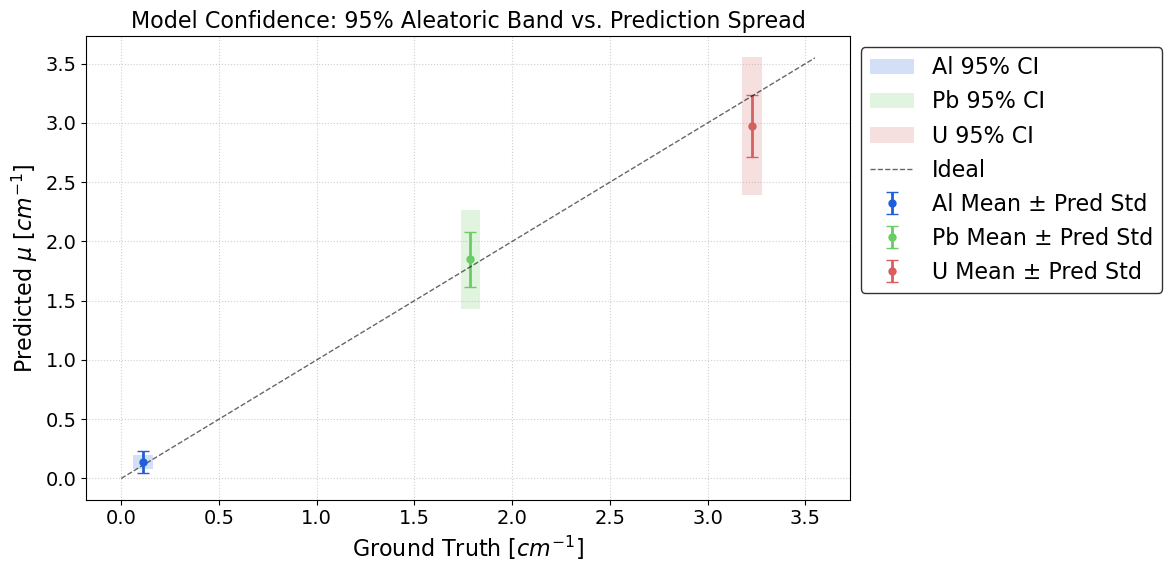

In [83]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 6))

for mat in data.keys():
    d = data[mat]
    truth_val = d["truth"].mean()
    mu_mean   = d["mu"].mean()
    mu_std    = d["mu"].std()
    # 95% CI is roughly 1.96 * std
    sig_95    = 1.96 * np.sqrt(d["sigma"]).mean() 

    color = MAT_COLORS[mat]

    # 1. Plot the 95% Confidence Interval as a shaded box or band
    # This represents the model's inner belief (Aleatoric)
    rect = patches.Rectangle((truth_val - 0.05, mu_mean - sig_95), 0.1, 2 * sig_95,
                             linewidth=0, facecolor=color, alpha=0.2, label=f"{mat} 95% CI")
    ax.add_patch(rect)

    # 2. Plot the Empirical Spread (mu_std) as a solid error bar
    # This represents how much the actual predictions vary
    ax.errorbar(truth_val, mu_mean, yerr=mu_std,
                fmt="o", color=color, ms=5, capsize=4, lw=2, 
                label=f"{mat} Mean ± Pred Std")

# Identity line
all_truths = [data[m]["truth"].mean() for m in data]
lo, hi = 0, max(all_truths) * 1.1
ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6, label="Ideal")

ax.set_xlabel(r"Ground Truth [$cm^{-1}]$")
ax.set_ylabel("Predicted $\mu$ [$cm^{-1}]$")
ax.set_title("Model Confidence: 95% Aleatoric Band vs. Prediction Spread")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### inspecting the scatter plot of the preds

/tmp/ipykernel_3928521/209236532.py:71: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


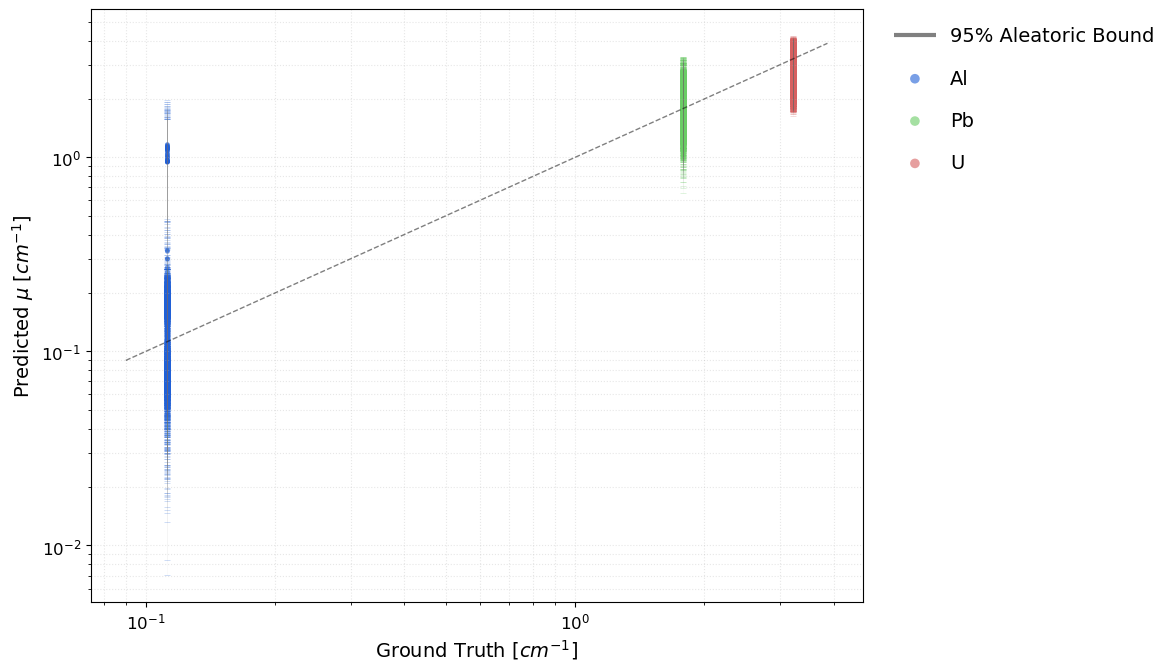

In [84]:
fig, ax = plt.subplots(figsize=(12, 7))

# Legend proxy
band_proxy = mlines.Line2D([], [], color='b', marker='_', markersize=10, 
                           linestyle='none', markeredgewidth=2, label='95% Aleatoric Bound')

for mat in data.keys():
    d = data[mat]
    truth = d["truth"]
    mu    = d["mu"]
    sig_95 = 1.96 * np.sqrt(d["sigma"]) 
    color = MAT_COLORS[mat]

    # 1. Plot the "Caps" only (Top and Bottom of the band)
    # This makes the boundaries visible even when the centers overlap
    ax.scatter(truth, mu + sig_95, marker='_', color=color, s=20, alpha=0.3, linewidths=0.5)
    ax.scatter(truth, mu - sig_95, marker='_', color=color, s=20, alpha=0.3, linewidths=0.5)

    # 2. Plot a very thin "Hair" connecting them
    ax.vlines(truth, mu - sig_95, mu + sig_95, color='gray', alpha=0.05, linewidth=0.5)

    # 3. Plot the Prediction points
    ax.scatter(truth, mu, color=color, s=12, alpha=0.6, edgecolors='none', label=mat)

# Identity line
all_vals = np.concatenate([data[m]["truth"] for m in data])
lo, hi = all_vals.min() * 0.8, all_vals.max() * 1.2
ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.5)

# log scale
ax.set_xscale('log')
ax.set_yscale('log')

# Legend setup
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(handles=[band_proxy] + list(by_label.values()), loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

# LEGEND IMPROVEMENTS
# 1. Create a larger, clearer proxy for the Aleatoric Band
band_proxy = mlines.Line2D([], [], color='gray', marker='_', markersize=15, 
                           linestyle='none', markeredgewidth=3, label='95% Aleatoric Bound')

# 2. Get the material handles
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# 3. Build the combined legend with larger font
all_handles = [band_proxy] + list(by_label.values())

ax.legend(
    handles=all_handles, 
    loc='upper left', 
    bbox_to_anchor=(1.02, 1), # Moves legend slightly further right
    frameon=False,
    fontsize=14,              # MUCH LARGER FONT
    markerscale=2.0,          # DOUBLES the size of the dots in the legend
    handletextpad=0.8,        # More space between icon and label
    labelspacing=1.2          # More vertical space between items
)

# Increase the size of the axis tick labels to match
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlabel(r"Ground Truth [$cm^{-1}$]", fontsize=14)
ax.set_ylabel(r"Predicted $\mu$ [$cm^{-1}$]", fontsize=14)

plt.tight_layout()


ax.grid(True, which="both", ls=":", alpha=0.3)
plt.tight_layout()
plt.show()


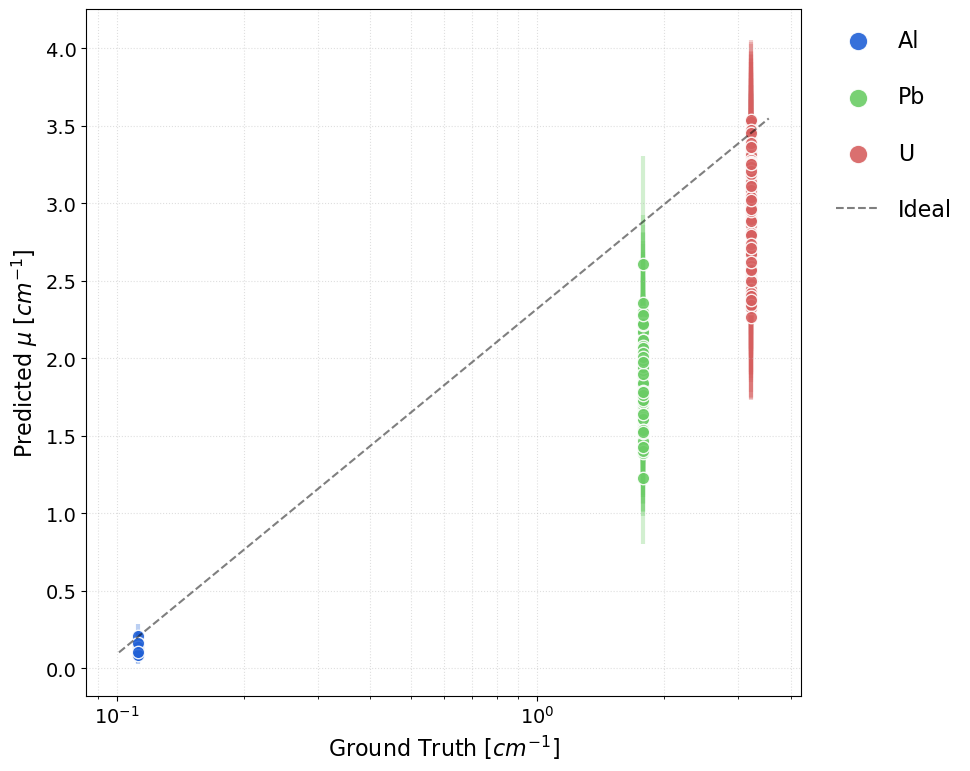

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(10, 8))


# Number of points to "zoom in" on per material
SAMPLES_PER_MAT = 100

for mat in data.keys():
    d = data[mat]
    color = MAT_COLORS[mat]
    
    # Sub-sample the data so we only see a "couple"
    indices = np.random.choice(len(d["truth"]), size=min(SAMPLES_PER_MAT, len(d["truth"])), replace=False)
    
    truth = d["truth"][indices]
    mu    = d["mu"][indices]
    sig_95 = 1.96 * np.sqrt(d["sigma"][indices])

    # 1. Plot the Aleatoric BAND (Wider linewidth for visibility)
    # Using 'vlines' with a thicker width makes the individual bands "pop"
    ax.vlines(truth, mu - sig_95, mu + sig_95, 
              color=color, alpha=0.3, linewidth=3, zorder=1)

    # 2. Plot the Mean Prediction (Larger markers)
    ax.scatter(truth, mu, color=color, s=80, alpha=0.9, 
               edgecolors='white', linewidths=1, label=mat, zorder=2)

# Identity line
all_vals = np.concatenate([data[m]["truth"] for m in data])
lo, hi = all_vals.min() * 0.9, all_vals.max() * 1.1
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5, alpha=0.5, label="Ideal")

# --- BIG LEGEND ---
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(handles= list(by_label.values()), 
          loc='upper left', bbox_to_anchor=(1.02, 1), 
          frameon=False, fontsize=16, markerscale=1.5, labelspacing=1.5)

# Axis Styling
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel(r"Ground Truth [$cm^{-1}$]", fontsize=16)
ax.set_ylabel(r"Predicted $\mu$ [$cm^{-1}$]", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(True, which="both", ls=":", alpha=0.4)

plt.tight_layout()
plt.show()


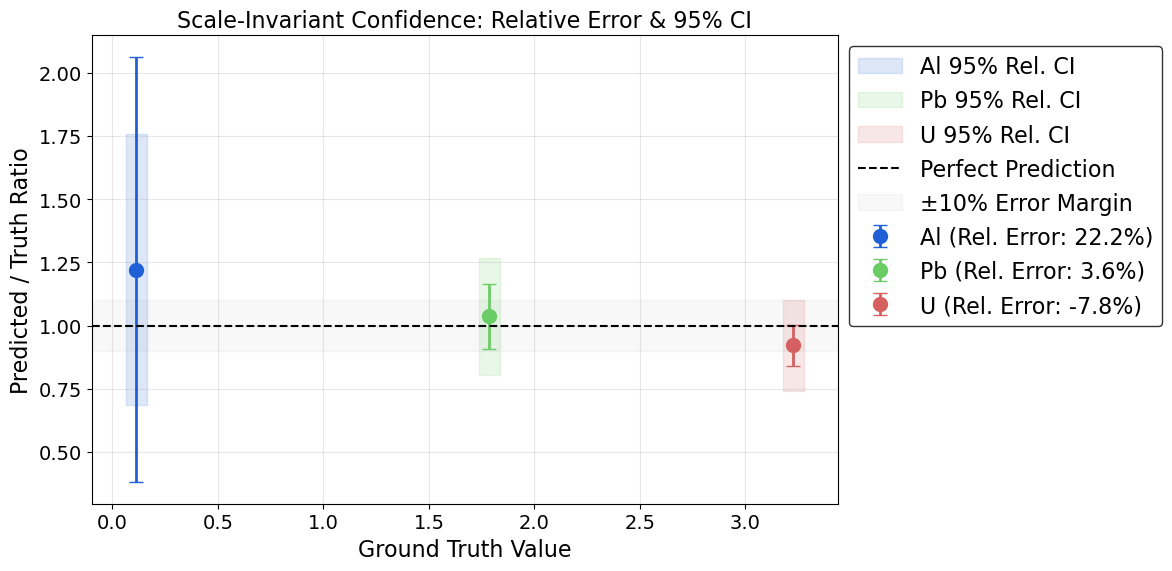

In [86]:
fig, ax = plt.subplots(figsize=(12, 6))

for mat in data.keys():
    d = data[mat]
    truth_val = d["truth"].mean()
    mu_mean   = d["mu"].mean()
    
    # CALCULATE RELATIVE VALUES (Scale-Invariant)
    ratio_mean = mu_mean / truth_val
    
    # Relative Prediction Spread (CV of predictions)
    rel_mu_std = d["mu"].std() / truth_val
    
    # Relative Learned Uncertainty (CV of model)
    # We use 1.96 for the 95% Confidence Interval
    rel_sig_95 = 1.96 * (np.sqrt(d["sigma"]).mean() / truth_val)

    color = MAT_COLORS[mat]

    # 1. Plot the 95% Relative Confidence Band (Model's belief)
    ax.fill_between([truth_val - 0.05, truth_val + 0.05], 
                    ratio_mean - rel_sig_95, 
                    ratio_mean + rel_sig_95, 
                    color=color, alpha=0.15, label=f"{mat} 95% Rel. CI")

    # 2. Plot the Relative Prediction Mean ± Spread
    ax.errorbar(truth_val, ratio_mean, yerr=rel_mu_std,
                fmt="o", color=color, ms=10, capsize=5, lw=2,
                label=f"{mat} (Rel. Error: {ratio_mean-1:.1%})")

# Ideal line (Ratio = 1.0)
ax.axhline(1.0, color="black", lw=1.5, ls="--", label="Perfect Prediction")

# Add a "Tolerance" shaded region (e.g., ±10% error)
ax.axhspan(0.9, 1.1, color='gray', alpha=0.05, label="±10% Error Margin")

ax.set_xlabel("Ground Truth Value")
ax.set_ylabel("Predicted / Truth Ratio")
ax.set_title("Scale-Invariant Confidence: Relative Error & 95% CI")
ax.legend( loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


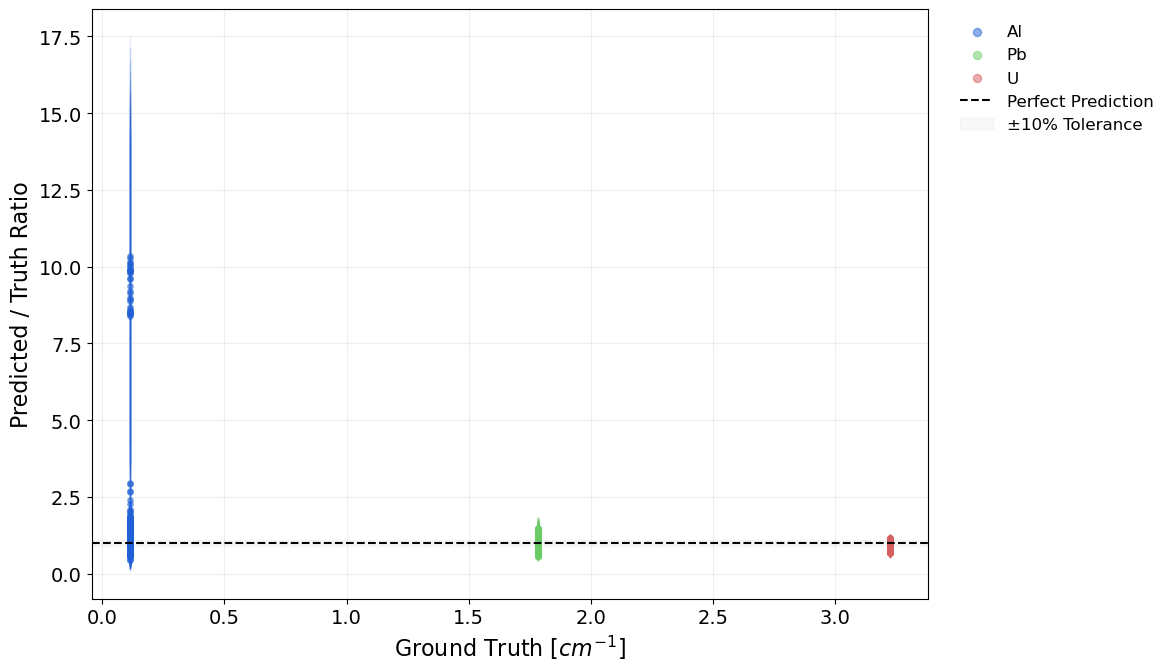

In [87]:
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(12, 7))

# 1. Create a proxy for the individual aleatoric bands in the legend
band_proxy = mlines.Line2D([], [], color='gray', alpha=0.3, linewidth=5, label='95% Aleatoric Band')

for mat in data.keys():
    d = data[mat]
    truth = d["truth"]
    mu    = d["mu"]
    # Calculate learned sigma for every point
    sig = np.sqrt(d["sigma"])
    
    # SCALE INVARIANT CALCULATIONS
    ratios     = mu / truth
    rel_sig_95 = 1.96 * (sig / truth)
    
    color = MAT_COLORS[mat]

    # 1. Plot individual 95% Aleatoric Bands (Vertical Lines)
    # This represents the model's self-reported confidence for each specific point
    ax.vlines(truth, ratios - rel_sig_95, ratios + rel_sig_95, 
              color=color, alpha=0.1, linewidth=1, zorder=1)

    # 2. Plot individual Prediction Ratios (Scatter)
    ax.scatter(truth, ratios, color=color, s=15, alpha=0.5, label=mat, zorder=2)

# Ideal line (Ratio = 1.0)
ax.axhline(1.0, color="black", lw=1.5, ls="--", label="Perfect Prediction")

# Add a "Tolerance" shaded region (±10% error)
ax.axhspan(0.9, 1.1, color='gray', alpha=0.05, label="±10% Tolerance")

# Scale the X-axis to see the range clearly
# ax.set_xscale('log') 
ax.set_xlabel(r"Ground Truth [$cm^{-1}$]")
ax.set_ylabel("Predicted / Truth Ratio")

# --- IMPROVED LEGEND ---
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
all_handles =list(by_label.values())

ax.legend(handles=all_handles, loc='upper left', bbox_to_anchor=(1.02, 1), 
          frameon=False, fontsize=12, markerscale=1.5)

ax.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()


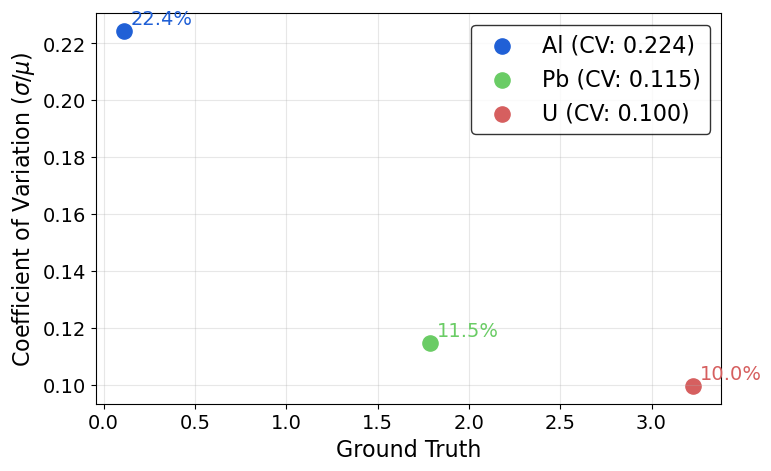

In [88]:
fig, ax = plt.subplots(figsize=(8, 5))

for mat in data.keys():
    d = data[mat]
    truth_val = d["truth"].mean()
    mu_mean   = d["mu"].mean()
    
    # Calculate the CV (Relative Uncertainty)
    sig_mean = np.sqrt(d["sigma"]).mean() 
    cv = sig_mean / mu_mean  # Learned relative uncertainty
    
    color = MAT_COLORS[mat]

    # Plot CV vs Truth
    ax.scatter(truth_val, cv, color=color, s=120, label=f"{mat} (CV: {cv:.3f})")
    
    # add a label next to the point
    ax.annotate(f"{cv:.1%}", (truth_val, cv), xytext=(5, 5), 
                textcoords='offset points', fontsize=14, color=color)

ax.set_xlabel("Ground Truth")
ax.set_ylabel("Coefficient of Variation ($\sigma / \mu$)")
ax.grid(True, alpha=0.3)
ax.legend()

# Set y-axis to log scale if the difference is "orders of magnitude"
# ax.set_yscale('log') 

plt.tight_layout()
plt.show()


In [89]:
for mat in data.keys():
    d = data[mat]
    ratio = np.sqrt(d["sigma"]).mean() / abs(d["mu"] - d["truth"]).mean()
    print(f"{mat}: mean_sigma/mean_residual = {ratio:.2f}  (>1 means sigma inflated)")

Al: mean_sigma/mean_residual = 1.04  (>1 means sigma inflated)
Pb: mean_sigma/mean_residual = 1.17  (>1 means sigma inflated)
U: mean_sigma/mean_residual = 1.01  (>1 means sigma inflated)


In [90]:
for mat in data.keys():
    d = data[mat]
    print(f"{mat}: bias={d['mu'].mean() - d['truth'].mean():.4f}  "
          f"(mu_mean={d['mu'].mean():.3f}, truth={d['truth'].mean():.3f})")

Al: bias=0.0249  (mu_mean=0.137, truth=0.112)
Pb: bias=0.0641  (mu_mean=1.850, truth=1.786)
U: bias=-0.2531  (mu_mean=2.973, truth=3.226)
